# ARBOLES DE DECISION. MODELOS "ENSEMBLE"

Vamos a estudiar el **comportamiento en la clasificación y los hiperparámetros del ÁRBOL DE DECISIÓN**. De nuevo utilizaremos como herramienta didáctica las gráficas de las fronteras de decisión con los 2 atributos relativos al pétalo del dataset "iris", con los que se obtiene una mejor separación entre clases y podemos graficar en el plano (2D).


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

#from sklearn.metrics import mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree, export_graphviz
#from sklearn.tree import export_graphviz


import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


## Carga del dataset "iris" y repaso previo:

**Carga del dataset:**

In [ ]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True, as_frame=True)

X.shape, y.shape

In [ ]:
X.head()

In [ ]:
# "arreglamos" nombres columnas atributos
columnas = [columna[:-5].replace(" ","_") for columna in X.columns]

X.columns = columnas

X.columns

**Creamos el dataframe:**

In [ ]:
iris_df = X.copy()

iris_df['especie_iris']= y

iris_df.info()

In [ ]:
# solo tiene atributos numéricos

target = 'especie_iris'

var_num = iris_df.columns.to_list()

var_num.remove(target)


**Repasamos brevemente la distribución de los 4 atributos numéricos y su relación con el target:**

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(8, 18), gridspec_kw={'hspace': 0.5})
colores = sns.color_palette("tab10", n_colors=4)


for idx, numerica in enumerate(var_num):

    sns.histplot(x=numerica, data=iris_df, kde=True, ax=axes[idx], bins=30, color=colores[idx])
    axes[idx].set_title(f'Histograma {numerica}')



In [ ]:
sns.pairplot(data=iris_df, hue='especie_iris', palette={0: 'red', 1: 'green', 2: 'blue'})

Los atributos del pétalo separan mejor entre clases.

**En cuanto al target:**

In [ ]:
y.unique()

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
y.value_counts()

In [ ]:
fig = plt.figure(figsize=(5,3))

ax1 = fig.add_subplot()

sns.countplot(x='especie_iris', data=iris_df)

ax1.set_title('ESPECIES IRIS')
ax1.set_xticklabels(['setosa', 'versicolor', 'virginica'])


## Particionado TRAIN-TEST

Realizamos el particionado:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_test.shape

Una de las ventajas del árbol de decisión es que **no necesita de preprocesado de los datos (escalado).**

Nos quedamos con los 2 ultimos atributos, los del pétalo:

In [ ]:
X.columns

In [ ]:
X2train = X_train.iloc[:,2:].copy()
X2test = X_test.iloc[:,2:].copy()

X2train.shape, X2test.shape

## ÁRBOL DE DECISIÓN

Entre los **hiperparámetros más utilizados** (y que podamos utilizar con los 2 atributos fijos elegidos) en el **árbol de decisión, tienen todos el propósito de hacer "pre-prunning"**, es decir evitar que el árbol se "desarrolle" por completo (lo que lleva al overfitting)

El **efecto de todos en las fronteras de decisión** es por consecuencia **el mismo (evitar nuevas divisiones en el plano).**

Por lo tanto vamos a comparar el modelo completo (por tanto sobreentrenado) con un modelo "pruneado" (recortado) por uno cualquiera de los hiperparametros.

Elegimos de entre ellos **"max_depth"**. Tenemos la oportunidad de probar con varias "profundidades" del árbol, aparte de que **si se le da el valor "None" (nulo) no pone límite alguno (modelo completo)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

max_depth = [1, 2, 3, 4, 5,None]

acc_train = []
acc_test = []

models = []


for depth in max_depth:

    d_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    d_tree.fit(X2train, y_train)

    acc_train.append(d_tree.score(X2train, y_train))
    acc_test.append(d_tree.score(X2test, y_test))

    models.append(d_tree)




In [ ]:
pd.DataFrame({'max_depth': max_depth, 'acc_train': acc_train, 'acc_test': acc_test})

**Vamos a separar el modelo más desarrollado (sin poda, recorte) y otro pruneado, para ver ver sus representaciones gráficas:**

In [ ]:
modelo_sin_recortar = models[5]

modelo_sin_recortar

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo_sin_recortar.get_depth()}")
print(f"Número de nodos terminales: {modelo_sin_recortar.get_n_leaves()}")

plot = plot_tree(
    decision_tree = modelo_sin_recortar,
    feature_names = var_num[2:],
    filled        = True,
    impurity      = False,
    fontsize      = 10,
    precision     = 2,
    ax            = ax
)




In [ ]:
modelo_recortado = models[2]

modelo_recortado

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo_recortado.get_depth()}")
print(f"Número de nodos terminales: {modelo_recortado.get_n_leaves()}")

plot = plot_tree(
    decision_tree = modelo_recortado,
    feature_names = var_num[2:],
    filled        = True,
    impurity      = False,
    fontsize      = 10,
    precision     = 2,
    ax            = ax
)




**Podemos ver en los nodos hoja de la derecha que hay 2 observaciones (filas) mal clasificadas, como fruto del recorte**

### Fronteras de decisión según "max_depth"

In [ ]:
from matplotlib.colors import ListedColormap


# Definimos la función que nos graficará las fronteras de decisión

def plot_decision_boundaries(model, X, y, delta: float = .02) -> None:
    """Plot data points and deicision boundaries learned by the model.

    Arguments:
    ----------
    model: scikit-learn like model

    X: np.array[n_samples, n_features]
        Only first 2 features will be considered because it is a 2d plot.
        Feature 0 in the x axis, and feature 1 in the y axis.

    y: np.array
        Labels for each sample.

    delta: float
        Increment between consecutive points when computing the grid for plotting boundaries.
        Lower value for higher resolution.
    """

    # Creamos la meshgrid con los valores mínimo y máximo de 'x' i 'y'.
    # La variable X es nuestro dataframe con las variables a estudiar (las del pétalo o las del sépalo)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, delta),
                         np.arange(y_min, y_max, delta))

    #Predecimos el clasificador con los valores de la meshgrid
    # En este caso model será nuestra variable que contiene el modelo a estudiar, es decir K-nn, SVM,...
    # Por ejemplo para K-nn sería model = KNeighborsClassifier()

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Creamos mapas de colores con ListedColormap para ver como separa las clases.
    # En este caso usaremos:
    # Iris-setosa : darkorange
    # Iris-versicolor: c
    # Iris-virginica: darkblue

    cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
    cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

    # Ponemos el resultado en una figura de color
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap= cmap_light)

    # Dibujamos también los puntos de entrenamiento
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap= cmap_bold)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

In [ ]:
for depth, model in zip(max_depth, models):

    print(f'MAX DEPTH: {depth}')
    plot_decision_boundaries(model, X2train.values, y_train)

    print('\n'*2)


**Resultados similares se obtienen de utilizar los hiperparámetros "min_samples_plit" o "max_leaf_nodes"**, además con menos control sobre el resultado que con "max_depth".

### FEATURE IMPORTANCES

Vamos a entrenar en este caso un nodelo con todos los 4 atributos y profundidad 3, para probar el método "feature_importances_"

In [ ]:
X_train.shape

In [ ]:
modelo_feature = DecisionTreeClassifier(max_depth=3, random_state=42)

modelo_feature.fit(X_train, y_train)

modelo_feature.score(X_train, y_train)

In [ ]:
modelo_feature.score(X_test, y_test)

In [ ]:
importancia_predictores = pd.DataFrame(
    {'predictor': var_num,
     'importancia': modelo_feature.feature_importances_}
)


importancia_predictores.sort_values('importancia', ascending=False)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo_feature.get_depth()}")
print(f"Número de nodos terminales: {modelo_feature.get_n_leaves()}")

plot = plot_tree(
    decision_tree = modelo_feature,
    feature_names = var_num,
    filled        = True,
    impurity      = False,
    fontsize      = 10,
    precision     = 2,
    ax            = ax
)




### Entrenamiento. Búsqueda de hiperparámetros con GRID SEARCH

Ahora emplearemos todos los atributos, **buscando el mejor modelo (mejores hiperparámetros) mediante una búsqueda en rejilla (grid search)**.

Entre todos los que actuan sobre el recorte ("prunning") del árbol elegimos **"max_depth" (máxima profundidad del árbol)**, y para añadir algo de "relajación" frente al sobreentrenamiento elegimos **"max_features" (nº de atributos elegidos al azar a utilizar en cada "split" de un nodo)**

In [ ]:
from sklearn.model_selection import GridSearchCV

d_tree = DecisionTreeClassifier(random_state=42)

# valores parámetros
param_grid = {'max_depth': [2,3,5,None], 'max_features': list(range(1,5))}

# por defecto 'GridSearchCV' utiliza validacion cruzada estratificada para clasificación
gs_dtree = GridSearchCV(d_tree, param_grid, cv=3, return_train_score=True, scoring='accuracy', refit=True, n_jobs=-1)


# X_train con todos los atributos
gs_dtree.fit(X_train,y_train)


print('Mejores parámetros:', gs_dtree.best_params_)


In [ ]:
gs_dtree.score(X_test,y_test)

In [ ]:
gs_dtree.score(X_train,y_train)

In [ ]:
gs_dtree.best_estimator_

Echemos un vistazo a los **resultados ('mean_test_score') de la validación cruzada:**

In [ ]:
# precisiones medias obtenidas (test validacion cruzada), redimensionamos (nº valores max_depths, nº valores n_estimators)
# para representacion 'heatmap'
scores_dtree = gs_dtree.cv_results_['mean_test_score'].reshape(4, 4)

# crear dataframe auxiliar representacion
dataframe = pd.DataFrame(scores_dtree, index=param_grid['max_depth'], columns=param_grid['max_features'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Wistia', fmt='.3g')
plt.title('Precision segun parametros')
plt.tight_layout(), plt.xlabel('nº atributos'), plt.ylabel('profundidad');

Y por último a la **matriz de confusión:**

In [ ]:
from sklearn.metrics import confusion_matrix


# por defecto parámetro "refit"=True, vuelve a entrenar con los mejores hiperparámetros obtenidos
# con toda la partición TRAIN
y_pred_tree = gs_dtree.predict(X_test)


mat_conf = confusion_matrix(y_test, y_pred_tree)

# crear dataframe auxiliar
dataframe = pd.DataFrame(mat_conf, index=['setosa', 'versicolor','virginica'], columns=['setosa', 'versicolor','virginica'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Reds')
plt.title('Confusion Matrix')

plt.tight_layout(), plt.xlabel('Predicted Values'), plt.ylabel('True Values');

## RANDOM FOREST

Vamos a buscar el **mejor modelo (hiperparámetros) con las dos posibilidades, búsqueda en rejilla** con los a priori 2 de los parámetros mas influyentes (representación gráfica) y **búsqueda aleatoria** con algún hiperparámetro más.

Dada la **aleatoriedad intrínseca de este modelo**(consecuencia de algunos de sus hiperparámetros) **no tiene sentido comparar varias gráficas de fronteras de decisión (no visualizariamos consecuencias válidas)**. Dibujaremos la del mejor modelo encontrado.

### Grid Search con 2 atributos

En primer lugar emplearemos **búsqueda en rejilla para los parámetros "n_estimators" (nº de árboles) y "max_features" (aleatoriedad)**:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {'n_estimators': [5,10,20,50], 'max_features': list(range(1,5))}


gs_RFC = GridSearchCV(RFC, param_grid, cv=5, return_train_score=True, scoring='accuracy')

gs_RFC.fit(X_train,y_train)


print('Mejores parámetros:', gs_RFC.best_params_)


Echemos un vistazo a los **resultados ('mean_test_score') de la validación cruzada:**

In [ ]:
# precisiones medias obtenidas (test validacion cruzada), redimensionamos (nº valores max_depths, nº valores n_estimators)
# para representacion 'heatmap'
scores_RFC = gs_RFC.cv_results_['mean_test_score'].reshape(4, 4)

# crear dataframe auxiliar representacion
dataframe = pd.DataFrame(scores_RFC, index=param_grid['n_estimators'], columns=param_grid['max_features'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Wistia', fmt='.3g')
plt.title('Precision segun parametros')
plt.tight_layout(), plt.xlabel('nº atributos'), plt.ylabel('Nº árboles');

### Random Search

Vamos ahora a realizar **búsqueda aleatoria** entre los hiperparámetros **"max_depth" (regularización) y "max_samples" y "max_features" (ambos aleatoriedad del modelo)**

In [ ]:

from sklearn.model_selection import RandomizedSearchCV

RFC = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {'max_depth': [2,3,5,None], 'max_features': list(range(1,5)), 'max_samples': [0.25,0.50,0.75,1]}


rs_RFC = RandomizedSearchCV(RFC, param_distributions, cv=3, return_train_score=True, scoring='accuracy')

rs_RFC.fit(X_train,y_train)


print('Mejores parámetros:', rs_RFC.best_params_)


In [ ]:
rs_RFC.score(X_test, y_test)

Veamos la **matriz de confusión:**

In [ ]:
# por defecto parámetro "refit"=True, vuelve a entrenar con los mejores hiperparámetros obtenidos
# con toda la partición TRAIN
y_pred_rsRFC = rs_RFC.predict(X_test)


mat_conf = confusion_matrix(y_test, y_pred_rsRFC)

# crear dataframe auxiliar
dataframe = pd.DataFrame(mat_conf, index=['setosa', 'versicolor','virginica'], columns=['setosa', 'versicolor','virginica'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Reds')
plt.title('Confusion Matrix')

plt.tight_layout(), plt.xlabel('Predicted Values'), plt.ylabel('True Values');

### Fronteras de decisión del mejor modelo

Hacemos la búsqueda sobre el dataset formado sólo con los 2 atributos del pétalo:

In [ ]:
Xtrain2 = X_train.iloc[:,2:].copy()
Xtest2 = X_test.iloc[:,2:].copy()

Xtrain2.shape, Xtest2.shape

In [ ]:
RFC = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {'max_depth': [2,None], 'max_features': [2,4], 'max_samples': [0.50,1]}


rs_RFC2 = RandomizedSearchCV(RFC, param_distributions, cv=5, return_train_score=True, scoring='accuracy')

rs_RFC2.fit(Xtrain2, y_train)


print('Mejores parámetros:', rs_RFC2.best_params_)


In [ ]:
plot_decision_boundaries(rs_RFC2.best_estimator_, Xtrain2.values, y_train)

## XGBOOST

Procederemos con los mismos pasos realizados con el modelo Random Forest anterior.

### Grid Search con 2 atributos

Pasamos a la **búsqueda en rejilla para los parámetros "n_estimators" (nº de árboles) y "learning_rate"**:

In [ ]:
from xgboost.sklearn import XGBClassifier


xgb = XGBClassifier()

param_grid = {'n_estimators': [5,10,20,50], 'learning_rate': [0.001,0.01,0.1,1]}


gs_xgb = GridSearchCV(xgb, param_grid, cv=3, return_train_score=True, scoring='accuracy')

gs_xgb.fit(X_train,y_train)


print('Mejores parámetros:', gs_xgb.best_params_)


Echemos un vistazo a los **resultados ('mean_test_score') de la validación cruzada:**

In [ ]:
# precisiones medias obtenidas (test validacion cruzada), redimensionamos (nº valores max_depths, nº valores n_estimators)
# para representacion 'heatmap'
scores_xgb = gs_xgb.cv_results_['mean_test_score'].reshape(4, 4)

# crear dataframe auxiliar representacion
dataframe = pd.DataFrame(scores_xgb, index=param_grid['n_estimators'], columns=param_grid['learning_rate'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Wistia', fmt='.3g')
plt.title('Precision segun parametros')
plt.tight_layout(), plt.xlabel('learning rate'), plt.ylabel('nº árboles');

### Random Search

Vamos a **fijar el nº de arboles a 10** y a buscar ahora entre más hiperparámetros:

In [ ]:
xgb = XGBClassifier(n_estimators=10)

param_distributions = {'learning_rate': [0.001,0.01,0.1,1], 'subsample': [0.25,0.50,0.75,1], 'colsample_bynode': [0.25,0.50,0.75,1]}


rs_xgb = RandomizedSearchCV(xgb, param_distributions, cv=5, return_train_score=True, scoring='accuracy')

rs_xgb.fit(X_train,y_train)


print('Mejores parámetros:', rs_xgb.best_params_)


In [ ]:
rs_xgb.score(X_test, y_test)

Veamos la **matriz de confusión:**

In [ ]:
y_pred_rs_xgb = rs_xgb.predict(X_test)


mat_conf = confusion_matrix(y_test, y_pred_rs_xgb)

# crear dataframe auxiliar
dataframe = pd.DataFrame(mat_conf, index=['setosa', 'versicolor','virginica'], columns=['setosa', 'versicolor','virginica'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Reds')
plt.title('Confusion Matrix')

plt.tight_layout(), plt.xlabel('Predicted Values'), plt.ylabel('True Values');

### Fronteras de decisión del mejor modelo

Disponemos ya del dataset formado sólo con los 2 atributos del pétalo:

In [ ]:
Xtrain2.shape, Xtest2.shape

In [ ]:
xgb = XGBClassifier(n_estimators=10)

param_distributions = {'learning_rate': [0.001,0.01,0.1,1], 'subsample': [0.25,0.50,0.75,1], 'colsample_bynode': [0.25,0.50,0.75,1]}


rs_xgb2 = RandomizedSearchCV(xgb, param_distributions, cv=5, return_train_score=True, scoring='accuracy')

rs_xgb2.fit(Xtrain2,y_train)


print('Mejores parámetros:', rs_xgb.best_params_)


In [ ]:
plot_decision_boundaries(rs_xgb2.best_estimator_, Xtrain2.values, y_train)

## COMPARACIÓN MODELOS ENSEMBLE

In [ ]:
rs_RFC.score(X_test, y_test)

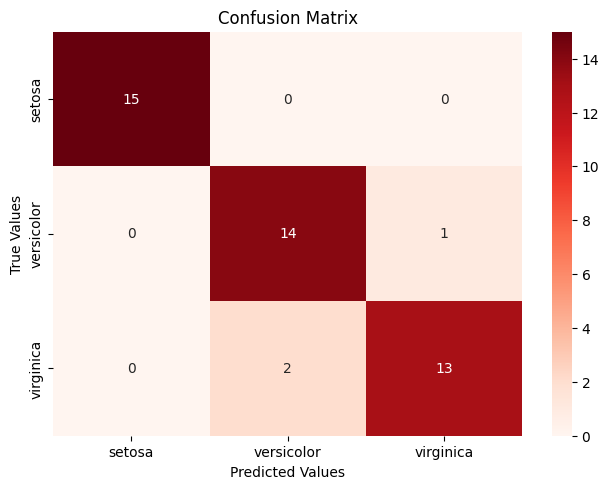

In [ ]:
rs_xgb.score(X_test, y_test)

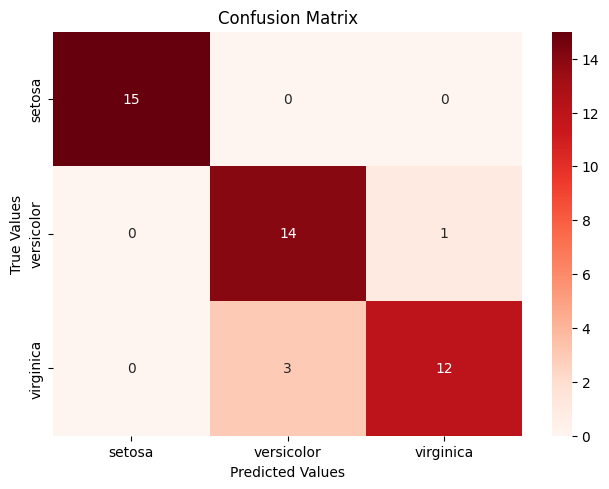